# 課題12 CLIP Zero-shot Image Classification

CLIP は画像エンコーダとテキストエンコーダを同じ embedding 空間へ写像するマルチモーダルモデルです。画像とテキストの類似度を計算できるため、学習なしで zero-shot 画像分類ができます。

この notebook では COCO 画像を使い、`a photo of a person`, `a photo of a bus`, `a photo of an airplane` などの text prompt と画像の類似度を比較します。

In [1]:
from pathlib import Path
import json
import os
import random
import numpy as np
import pandas as pd
import torch
from PIL import Image
import matplotlib.pyplot as plt

# 課題フォルダと保存先。
BASE_DIR = Path('/export/space0/oyundari/jupyter/notebook/kadai4/dnn_kadai2')
TASK_DIR = BASE_DIR / 'kadai12-clip_zero_shot'
OUT_DIR = TASK_DIR / 'out'
MODEL_DIR = TASK_DIR / 'model'
DATA_DIR = BASE_DIR / 'data'
LAB_COCO_DIR = Path('/export/data/dataset/COCO')
COCO_LINK = DATA_DIR / 'COCO'

OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

os.environ['CUDA_VISIBLE_DEVICES'] = '0'
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


In [2]:
# COCOはコピーせず、シンボリックリンクで使う。
if not COCO_LINK.exists():
    if not LAB_COCO_DIR.exists():
        raise FileNotFoundError(f'COCO dataset not found: {LAB_COCO_DIR}')
    os.symlink(LAB_COCO_DIR, COCO_LINK, target_is_directory=True)
print('COCO link:', COCO_LINK)

COCO link: /export/space0/oyundari/jupyter/notebook/kadai4/dnn_kadai2/data/COCO


## COCO 画像を選ぶ

CLIP zero-shot 分類が分かりやすいよう、COCO annotation から `person`, `bus`, `airplane`, `dog`, `cat` の画像を選びます。

In [3]:
def find_annotation_file(coco_dir):
    candidates = [
        coco_dir / 'annotations' / 'instances_val2014.json',
        coco_dir / 'annotations' / 'instances_train2014.json',
        coco_dir / 'annotations.org' / 'instances_val2014.json',
        coco_dir / 'annotations.org' / 'instances_train2014.json',
    ]
    for path in candidates:
        if path.exists():
            return path
    return None

def image_path_from_file_name(coco_dir, file_name):
    for split in ['val2014', 'train2014', 'test2014']:
        path = coco_dir / split / file_name
        if path.exists():
            return path
    matches = list(coco_dir.glob(f'**/{file_name}'))
    if matches:
        return matches[0]
    raise FileNotFoundError(file_name)

def select_coco_images(coco_dir, labels=('person', 'bus', 'airplane', 'dog', 'cat')):
    ann_path = find_annotation_file(coco_dir)
    selected = []
    used = set()
    if ann_path is not None:
        data = json.loads(ann_path.read_text())
        cat_name_to_id = {c['name']: c['id'] for c in data['categories']}
        image_id_to_file = {img['id']: img['file_name'] for img in data['images']}
        for label in labels:
            cat_id = cat_name_to_id.get(label)
            for ann in data['annotations']:
                if ann['category_id'] == cat_id and ann.get('area', 0) > 3000 and ann['image_id'] not in used:
                    selected.append({'label': label, 'path': image_path_from_file_name(coco_dir, image_id_to_file[ann['image_id']])})
                    used.add(ann['image_id'])
                    break
    if len(selected) < 3:
        paths = []
        for split in ['val2014', 'train2014']:
            root = coco_dir / split
            if root.exists():
                paths.extend(sorted(root.glob('*.jpg')))
        selected = [{'label': f'image_{i}', 'path': p} for i, p in enumerate(paths[:5])]
    return selected[:5]

selected = select_coco_images(COCO_LINK)
images = []
for item in selected:
    img = Image.open(item['path']).convert('RGB')
    images.append({**item, 'image': img})
    print(item['label'], item['path'])

person /export/space0/oyundari/jupyter/notebook/kadai4/dnn_kadai2/data/COCO/val2014/COCO_val2014_000000537548.jpg
bus /export/space0/oyundari/jupyter/notebook/kadai4/dnn_kadai2/data/COCO/val2014/COCO_val2014_000000017207.jpg
airplane /export/space0/oyundari/jupyter/notebook/kadai4/dnn_kadai2/data/COCO/val2014/COCO_val2014_000000504811.jpg
dog /export/space0/oyundari/jupyter/notebook/kadai4/dnn_kadai2/data/COCO/val2014/COCO_val2014_000000016164.jpg
cat /export/space0/oyundari/jupyter/notebook/kadai4/dnn_kadai2/data/COCO/val2014/COCO_val2014_000000157807.jpg


## CLIP model の読み込み

まず `model/clip-vit-base-patch32/` に手動配置したモデルを探します。無い場合だけ、`ALLOW_DOWNLOAD=True` にすると Hugging Face から取得します。

In [5]:
# 学内ネットワーク経由の場合はプロキシを設定
os.environ["http_proxy"]  = "http://proxy.uec.ac.jp:8080/"
os.environ["https_proxy"] = "http://proxy.uec.ac.jp:8080/"

# IPv6 を無効化（接続問題の回避）
os.environ["HF_HUB_DISABLE_IPV6"] = "1"

In [6]:
from huggingface_hub import login

# Hugging Face アクセストークンでログイン
login("")

In [8]:
ALLOW_DOWNLOAD = True

LOCAL_CLIP_DIR = MODEL_DIR / "clip-vit-base-patch32"
HF_CACHE_DIR = MODEL_DIR / "hf_cache"
HF_CACHE_DIR.mkdir(parents=True, exist_ok=True)

from transformers import CLIPProcessor, CLIPModel

if LOCAL_CLIP_DIR.exists():
    model_name_or_path = str(LOCAL_CLIP_DIR)
    local_only = True
else:
    model_name_or_path = "openai/clip-vit-base-patch32"
    local_only = not ALLOW_DOWNLOAD

print("CLIP model:", model_name_or_path)

processor = CLIPProcessor.from_pretrained(
    model_name_or_path,
    local_files_only=local_only,
    cache_dir=HF_CACHE_DIR,
)

clip_model = CLIPModel.from_pretrained(
    model_name_or_path,
    local_files_only=local_only,
    cache_dir=HF_CACHE_DIR,
).to(device).eval()

CLIP model: openai/clip-vit-base-patch32


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 31452.93it/s]
/home/yanai-lab/oyundari/miniconda3/envs/sd/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


## Zero-shot classification

分類候補を text prompt として用意し、画像とテキストの類似度を softmax で確率のように正規化します。学習なしで画像分類できる点が CLIP の特徴です。

In [9]:
class_names = ['person', 'bus', 'airplane', 'dog', 'cat', 'car', 'bicycle', 'food']
prompts = [f'a photo of a {name}' for name in class_names]

rows = []
for item in images:
    inputs = processor(text=prompts, images=item['image'], return_tensors='pt', padding=True).to(device)
    with torch.no_grad():
        outputs = clip_model(**inputs)
        probs = outputs.logits_per_image.softmax(dim=1)[0].detach().cpu().numpy()
    pred_idx = int(probs.argmax())
    row = {'image_label': item['label'], 'image_path': str(item['path']), 'prediction': class_names[pred_idx], 'confidence': float(probs[pred_idx])}
    for name, p in zip(class_names, probs):
        row[name] = float(p)
    rows.append(row)
    print(item['label'], '->', row['prediction'], row['confidence'])

df = pd.DataFrame(rows)
df.to_csv(OUT_DIR / 'clip_zero_shot_results.csv', index=False)
df

person -> person 0.5733932256698608
bus -> bus 0.9564696550369263
airplane -> airplane 0.9730499386787415
dog -> dog 0.979754626750946
cat -> cat 0.9891332983970642


,image_label,image_path,prediction,confidence,person,bus,airplane,dog,cat,car,bicycle,food
0,person,/export/space0/oyundari/jupyter/notebook/kadai...,person,0.573393,0.573393,0.011628,0.002529,0.028407,0.015532,0.095984,0.271050,0.001478
1,bus,/export/space0/oyundari/jupyter/notebook/kadai...,bus,0.956470,0.006383,0.956470,0.000094,0.000661,0.001225,0.017152,0.015916,0.002099
2,airplane,/export/space0/oyundari/jupyter/notebook/kadai...,airplane,0.973050,0.004628,0.003151,0.973050,0.000848,0.000445,0.012943,0.004396,0.000539
3,dog,/export/space0/oyundari/jupyter/notebook/kadai...,dog,0.979755,0.005710,0.000236,0.000650,0.979755,0.009788,0.000585,0.000957,0.002320
4,cat,/export/space0/oyundari/jupyter/notebook/kadai...,cat,0.989133,0.004172,0.000078,0.000103,0.004544,0.989133,0.000086,0.001014,0.000870


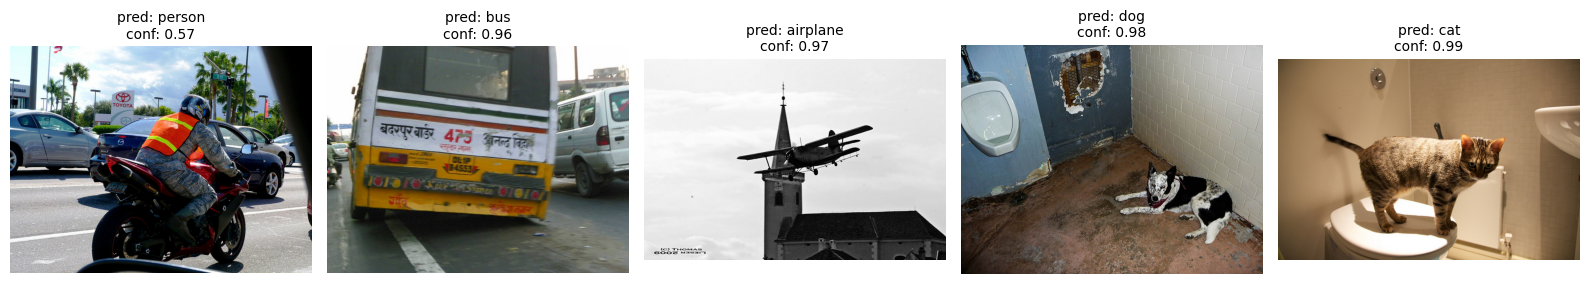

saved: /export/space0/oyundari/jupyter/notebook/kadai4/dnn_kadai2/kadai12-clip_zero_shot/out/clip_zero_shot_results.png


In [10]:
# 画像とCLIP予測結果をまとめて保存する。
cols = len(images)
plt.figure(figsize=(cols * 3.2, 4.2))
for i, item in enumerate(images):
    row = rows[i]
    plt.subplot(1, cols, i + 1)
    plt.imshow(item['image'])
    plt.axis('off')
    plt.title(f"pred: {row['prediction']}\nconf: {row['confidence']:.2f}", fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR / 'clip_zero_shot_results.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('saved:', OUT_DIR / 'clip_zero_shot_results.png')

## まとめ

CLIP は画像とテキストを同じ embedding 空間へ写像するため、学習済み分類 head がなくても text prompt をカテゴリとして使えます。これにより、COCO 画像に対して zero-shot 画像分類を行えることを確認しました。